<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Jackknife.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <span style="color:green;">**Jackknife**</span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span> Aplicar el método Jackknife a una muestra de tiempos de entrega para evaluar la estabilidad de la media muestral y estimar su variabilidad. Mediante la eliminación sistemática de una observación a la vez, se busca obtener una estimación de la varianza, la desviación estándar y construir un intervalo de confianza del $95\%$, sin asumir una distribución probabilística específica para los datos.

Tenemos una muestra de $n$ datos, En esta técnica eliminamos uno de los datos para obtener $n$ muestras de tamaño $n-1$.

Para cada muestra calculamos el estadístico $\hat{θ}_i$ y luego obtemos el promedio del **Jackknife**:

$$
θ=\frac{1}{n} ∑_{i=1}^n \hat{θ}_i
$$

Y la varianza
$$
var_{Jac}=\frac{n-1}{n} ∑_{i=1}^n (θ-\hat{θ}_i)^2
$$

<span style="color:teal;">**Ejercicio:**</span> Esta es una muestra aleatoria de 12 tiempos de entrega;

$$
35,42,38,40,45,37,39,41,44,36,43,40
$$

**Instrucciones:**

1. Use la muestra original de 12 observaciones y aplique Jackknife

2. Calcular la **var**

3. Al final:

* Clacule la desviación estándar.
* Determine los porcentiles $2.5\%$ y $97.5\%$ para construir el  intervalo de confianza $B$ del $95\%$

Este metodo consite en crear muestras $n$ de tamaño $n-1$; es decir creamos $12$ muestras de tamaño $11$.

In [18]:
#Importación de librerías
import numpy as np
import matplotlib.pyplot as plt

In [19]:
datos = np.array([         #Datos de la muestra
    35, 42, 38, 40, 45, 37,
    39, 41, 44, 36, 43, 40
])

In [20]:
datos

array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

Contamos los datos para saber el número de estas:

In [21]:
n = len(datos)#contar lo datos

In [22]:
n

12

 Generamos las muestras Jackknife de tamaño $11$

In [23]:
estimadores = [] #creamos una lista vacia para almacenar las muestras

for i in range(n):
    # Eliminar la observación i
    muestra_jack = np.delete(datos, i)
    # Estadístico de interés: media
    theta_i = np.mean(muestra_jack)
    estimadores.append(theta_i)
estimadores = np.array(estimadores)

In [24]:
estimadores

array([40.45454545, 39.81818182, 40.18181818, 40.        , 39.54545455,
       40.27272727, 40.09090909, 39.90909091, 39.63636364, 40.36363636,
       39.72727273, 40.        ])

Calculamos el <span style="color:teal;">**Promedio Jackknife**</span>

$$
θ=\frac{1}{12} ∑_{i=1}^{12} \hat{θ}_i
$$

In [25]:
theta_jack = np.mean(estimadores)
theta_jack

np.float64(40.0)

El promedio $\bar{X}=40$

Procemos a calcular la <span style="color:teal;">**Varianza Jackknife**</span>

In [26]:
var_jack = ((n - 1)/n) * np.sum(
    (estimadores - theta_jack)**2
)
var_jack

np.float64(0.8333333333333355)

La varianza $σ^2=0.8333$

Calculamos la <span style="color:teal;">**Desviación estándar Jackknife**</span>

In [27]:
desv_jack = np.sqrt(var_jack)
desv_jack

np.float64(0.912870929175278)

Percentiles e intervalo de confianza

In [28]:
p025 = np.percentile(estimadores, 2.5)
p975 = np.percentile(estimadores, 97.5)

Finalmente Obteniendo los resultados

In [29]:
print("RESULTADOS JACKKNIFE")
print("="*60)
print(f"Número de observaciones = {n}")
print(f"\nPromedio Jackknife = {theta_jack:.6f}")
print(f"Varianza Jackknife = {var_jack:.6f}")
print(f"Desviación estándar = {desv_jack:.6f}")
print(f"\nPercentil 2.5%  = {p025:.6f}")
print(f"Percentil 97.5% = {p975:.6f}")

print(
    f"\nIC 95% = ({p025:.6f}, {p975:.6f})"
)


RESULTADOS JACKKNIFE
Número de observaciones = 12

Promedio Jackknife = 40.000000
Varianza Jackknife = 0.833333
Desviación estándar = 0.912871

Percentil 2.5%  = 39.570455
Percentil 97.5% = 40.429545

IC 95% = (39.570455, 40.429545)


Mostrando los estimadores Jackknife los cuales seran 12

In [30]:
for i, valor in enumerate(estimadores, start=1):
    print(f"θ_{i:2d} = {valor:.6f}")

θ_ 1 = 40.454545
θ_ 2 = 39.818182
θ_ 3 = 40.181818
θ_ 4 = 40.000000
θ_ 5 = 39.545455
θ_ 6 = 40.272727
θ_ 7 = 40.090909
θ_ 8 = 39.909091
θ_ 9 = 39.636364
θ_10 = 40.363636
θ_11 = 39.727273
θ_12 = 40.000000


A continuación mostramos una Gráfica de los <span style="color:teal;"> estimadores de **Jackknife**</span>

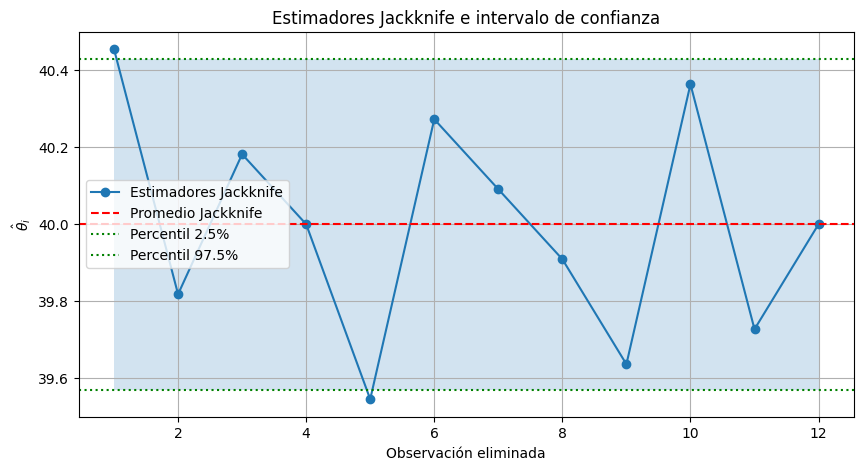

In [31]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1, n+1),
    estimadores,
    marker='o',
    label='Estimadores Jackknife'
)

plt.axhline(
    theta_jack,
    color='red',
    linestyle='--',
    label='Promedio Jackknife'
)

plt.axhline(
    p025,
    color='green',
    linestyle=':',
    label='Percentil 2.5%'
)

plt.axhline(
    p975,
    color='green',
    linestyle=':',
    label='Percentil 97.5%'
)

plt.fill_between(
    range(1, n+1),
    p025,
    p975,
    alpha=0.2
)

plt.xlabel('Observación eliminada')
plt.ylabel(r'$\hat{\theta}_i$')
plt.title('Estimadores Jackknife e intervalo de confianza')
plt.grid(True)
plt.legend()

plt.show()

<span style="color:teal;">**Interpretación**</span>

* Cada punto representa la media calculada después de eliminar una observación.
* La línea roja punteada corresponde al promedio Jackknife.
* Si los puntos están muy cerca de la línea roja, la estimación es estable.
* Si algún punto se aleja considerablemente, significa que la observación eliminada tiene una influencia importante sobre la media.

En conclusión la mayoría de los estimadores Jackknife se encuentran dentro de una banda estrecha alrededor de la media de 40, lo que indica que ninguna observación individual modifica drásticamente el resultado. Esto sugiere que la estimación de la media es robusta y que los tiempos de entrega presentan una variabilidad moderada respecto al promedio observado.

## <span style="color:green;"> **Conclusión**</span>

El método Jackknife permitió analizar la sensibilidad de la media muestral frente a la eliminación de cada observación de la muestra. Los estimadores obtenidos resultaron muy cercanos entre sí, lo que indica que la media es una medida estable y que ninguna observación individual ejerce una influencia excesiva sobre el resultado final.

Además, la varianza y la desviación estándar Jackknife proporcionaron una medida de la incertidumbre asociada a la estimación de la media. El intervalo de confianza del $95\%$ obtenido fue relativamente estrecho, sugiriendo que el tiempo promedio de entrega se encuentra bien determinado dado los datos disponibles.

En general el **método Jackknife** constituye una herramienta eficaz para evaluar la precisión y robustez de un estimador, permitiendo cuantificar su variabilidad a partir de la propia muestra y sin necesidad de realizar un gran número de simulaciones como en otros métodos de remuestreo.